# 04 — Métricas clássicas de avaliação

As fórmulas usadas para avaliar os predicados aprendidos estão documentadas em `results/metrics/metricas_classicas.md` (gerado por `src/analyze_training_results.py`). Este notebook reproduz o conteúdo e aplica as métricas às tabelas finais.

```text
Accuracy  = (TP + TN) / (TP + TN + FP + FN)
Precision = TP / (TP + FP)
Recall    = TP / (TP + FN)
F1 Score  = 2 * (Precision * Recall) / (Precision + Recall)
```

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display


def find_project_root(start: Path) -> Path:
    """Localiza a raiz do projeto subindo diretórios até achar src/ e requirements.txt."""
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Não foi possível localizar a raiz do projeto.")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data" / "datasets_gerados"
RESULTS_DIR = PROJECT_ROOT / "results"
METRICS_DIR = RESULTS_DIR / "metrics"
QUERIES_DIR = RESULTS_DIR / "queries"
TRAINING_DIR = RESULTS_DIR / "training"

print("Raiz do projeto:", PROJECT_ROOT)


Raiz do projeto: C:\Users\Sara IRMA\Documents\IA\Trabalho-Final-Raciocinio-Espacial-Neuro-Simbolico-com-LTNtorch


In [2]:
caminho_metricas_classicas = METRICS_DIR / "metricas_classicas.md"
display(Markdown(caminho_metricas_classicas.read_text(encoding="utf-8")))

# Métricas clássicas de avaliação

Este arquivo descreve as métricas clássicas utilizadas para avaliar os predicados aprendidos ou definidos no projeto LTN.

As métricas foram calculadas comparando as predições do modelo com a verdade-terreno.

## 1. Termos da matriz de confusão

Antes de definir as métricas, usamos quatro quantidades principais:

- **TP — True Positive:** casos positivos corretamente previstos como positivos.
- **TN — True Negative:** casos negativos corretamente previstos como negativos.
- **FP — False Positive:** casos negativos previstos incorretamente como positivos.
- **FN — False Negative:** casos positivos previstos incorretamente como negativos.

## 2. Accuracy

A **Accuracy** representa a proporção de instâncias corretamente classificadas entre todas as instâncias avaliadas.

Ela considera tanto os acertos positivos quanto os acertos negativos.

```text
Accuracy = (TP + TN) / (TP + TN + FP + FN)
```

Em notação matemática:

```latex
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
```

No projeto, essa métrica indica o percentual geral de acertos de cada predicado.

Entretanto, a Accuracy pode ser enganosa quando existe desbalanceamento de classes. Por exemplo, se uma relação possui muitos casos negativos e poucos positivos, um modelo pode obter alta Accuracy apenas prevendo quase tudo como negativo.

## 3. Precision

A **Precision** mede, entre todos os casos que o modelo classificou como positivos, quantos realmente eram positivos.

```text
Precision = TP / (TP + FP)
```

Em notação matemática:

```latex
\text{Precision} = \frac{TP}{TP + FP}
```

No projeto, uma Precision alta significa que, quando o modelo afirma que uma relação é verdadeira, ele costuma estar correto.

Por exemplo: se `canStack(x,y)` tem Precision alta, então os pares que o modelo identifica como empilháveis tendem a ser realmente empilháveis.

## 4. Recall

O **Recall**, também chamado de sensibilidade, mede a proporção de casos positivos reais que foram corretamente encontrados pelo modelo.

```text
Recall = TP / (TP + FN)
```

Em notação matemática:

```latex
\text{Recall} = \frac{TP}{TP + FN}
```

No projeto, um Recall alto significa que o modelo consegue encontrar a maioria dos exemplos verdadeiros de uma relação.

Por exemplo: se `inBetween(x,y,z)` tem Recall alto, então o modelo encontra boa parte das triplas em que um objeto realmente está entre dois outros.

## 5. F1 Score

O **F1 Score** é a média harmônica entre Precision e Recall.

Ele busca equilibrar a capacidade do modelo de evitar falsos positivos e, ao mesmo tempo, encontrar os positivos reais.

```text
F1 Score = 2 * (Precision * Recall) / (Precision + Recall)
```

Em notação matemática:

```latex
\text{F1 Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
```

No projeto, o F1 Score é especialmente importante para relações desbalanceadas, como `closeTo` e `canStack`.

Quando uma relação tem poucos exemplos positivos, a Accuracy pode parecer boa mesmo que o modelo não esteja aprendendo os positivos. Por isso, o F1 Score ajuda a avaliar melhor o desempenho real.

## 6. Interpretação no projeto LTN

As métricas foram usadas para avaliar os seguintes predicados binários:

- `leftOf`
- `rightOf`
- `below`
- `above`
- `closeTo`
- `canStack`

E o seguinte predicado ternário:

- `inBetween`

A leitura geral é:

- **Accuracy** mostra o acerto geral.
- **Precision** mostra a confiabilidade das previsões positivas.
- **Recall** mostra a capacidade de encontrar positivos reais.
- **F1 Score** mostra o equilíbrio entre Precision e Recall.

No contexto deste projeto, o F1 Score é a métrica mais importante para analisar relações com desbalanceamento de classes.


## Métricas finais — predicados binários

In [3]:
pd.read_csv(METRICS_DIR / "metricas_finais_binarias.csv")

,relacao,accuracy,precision,recall,f1,best_threshold,best_accuracy,best_precision,best_recall,best_f1
0,leftOf,0.848,0.833333,0.847458,0.840336,0.40,0.840,0.774648,0.932203,0.846154
1,rightOf,0.856,0.905660,0.786885,0.842105,0.45,0.856,0.890909,0.803279,0.844828
2,below,0.816,0.847826,0.709091,0.772277,0.40,0.792,0.716418,0.872727,0.786885
3,above,0.832,0.879310,0.784615,0.829268,0.45,0.848,0.838235,0.876923,0.857143
4,closeTo,1.000,1.000000,1.000000,1.000000,0.45,1.000,1.000000,1.000000,1.000000
5,canStack,0.784,0.510638,0.857143,0.640000,0.50,0.784,0.510638,0.857143,0.640000


## Métricas finais — predicado ternário

In [4]:
pd.read_csv(METRICS_DIR / "metricas_finais_ternarias.csv")

,relacao,accuracy,precision,recall,f1,best_threshold,best_accuracy,best_precision,best_recall,best_f1
0,inBetween,0.722101,0.692478,0.855776,0.765515,0.5,0.722101,0.692478,0.855776,0.765515


## Gráfico consolidado de F1 por predicado

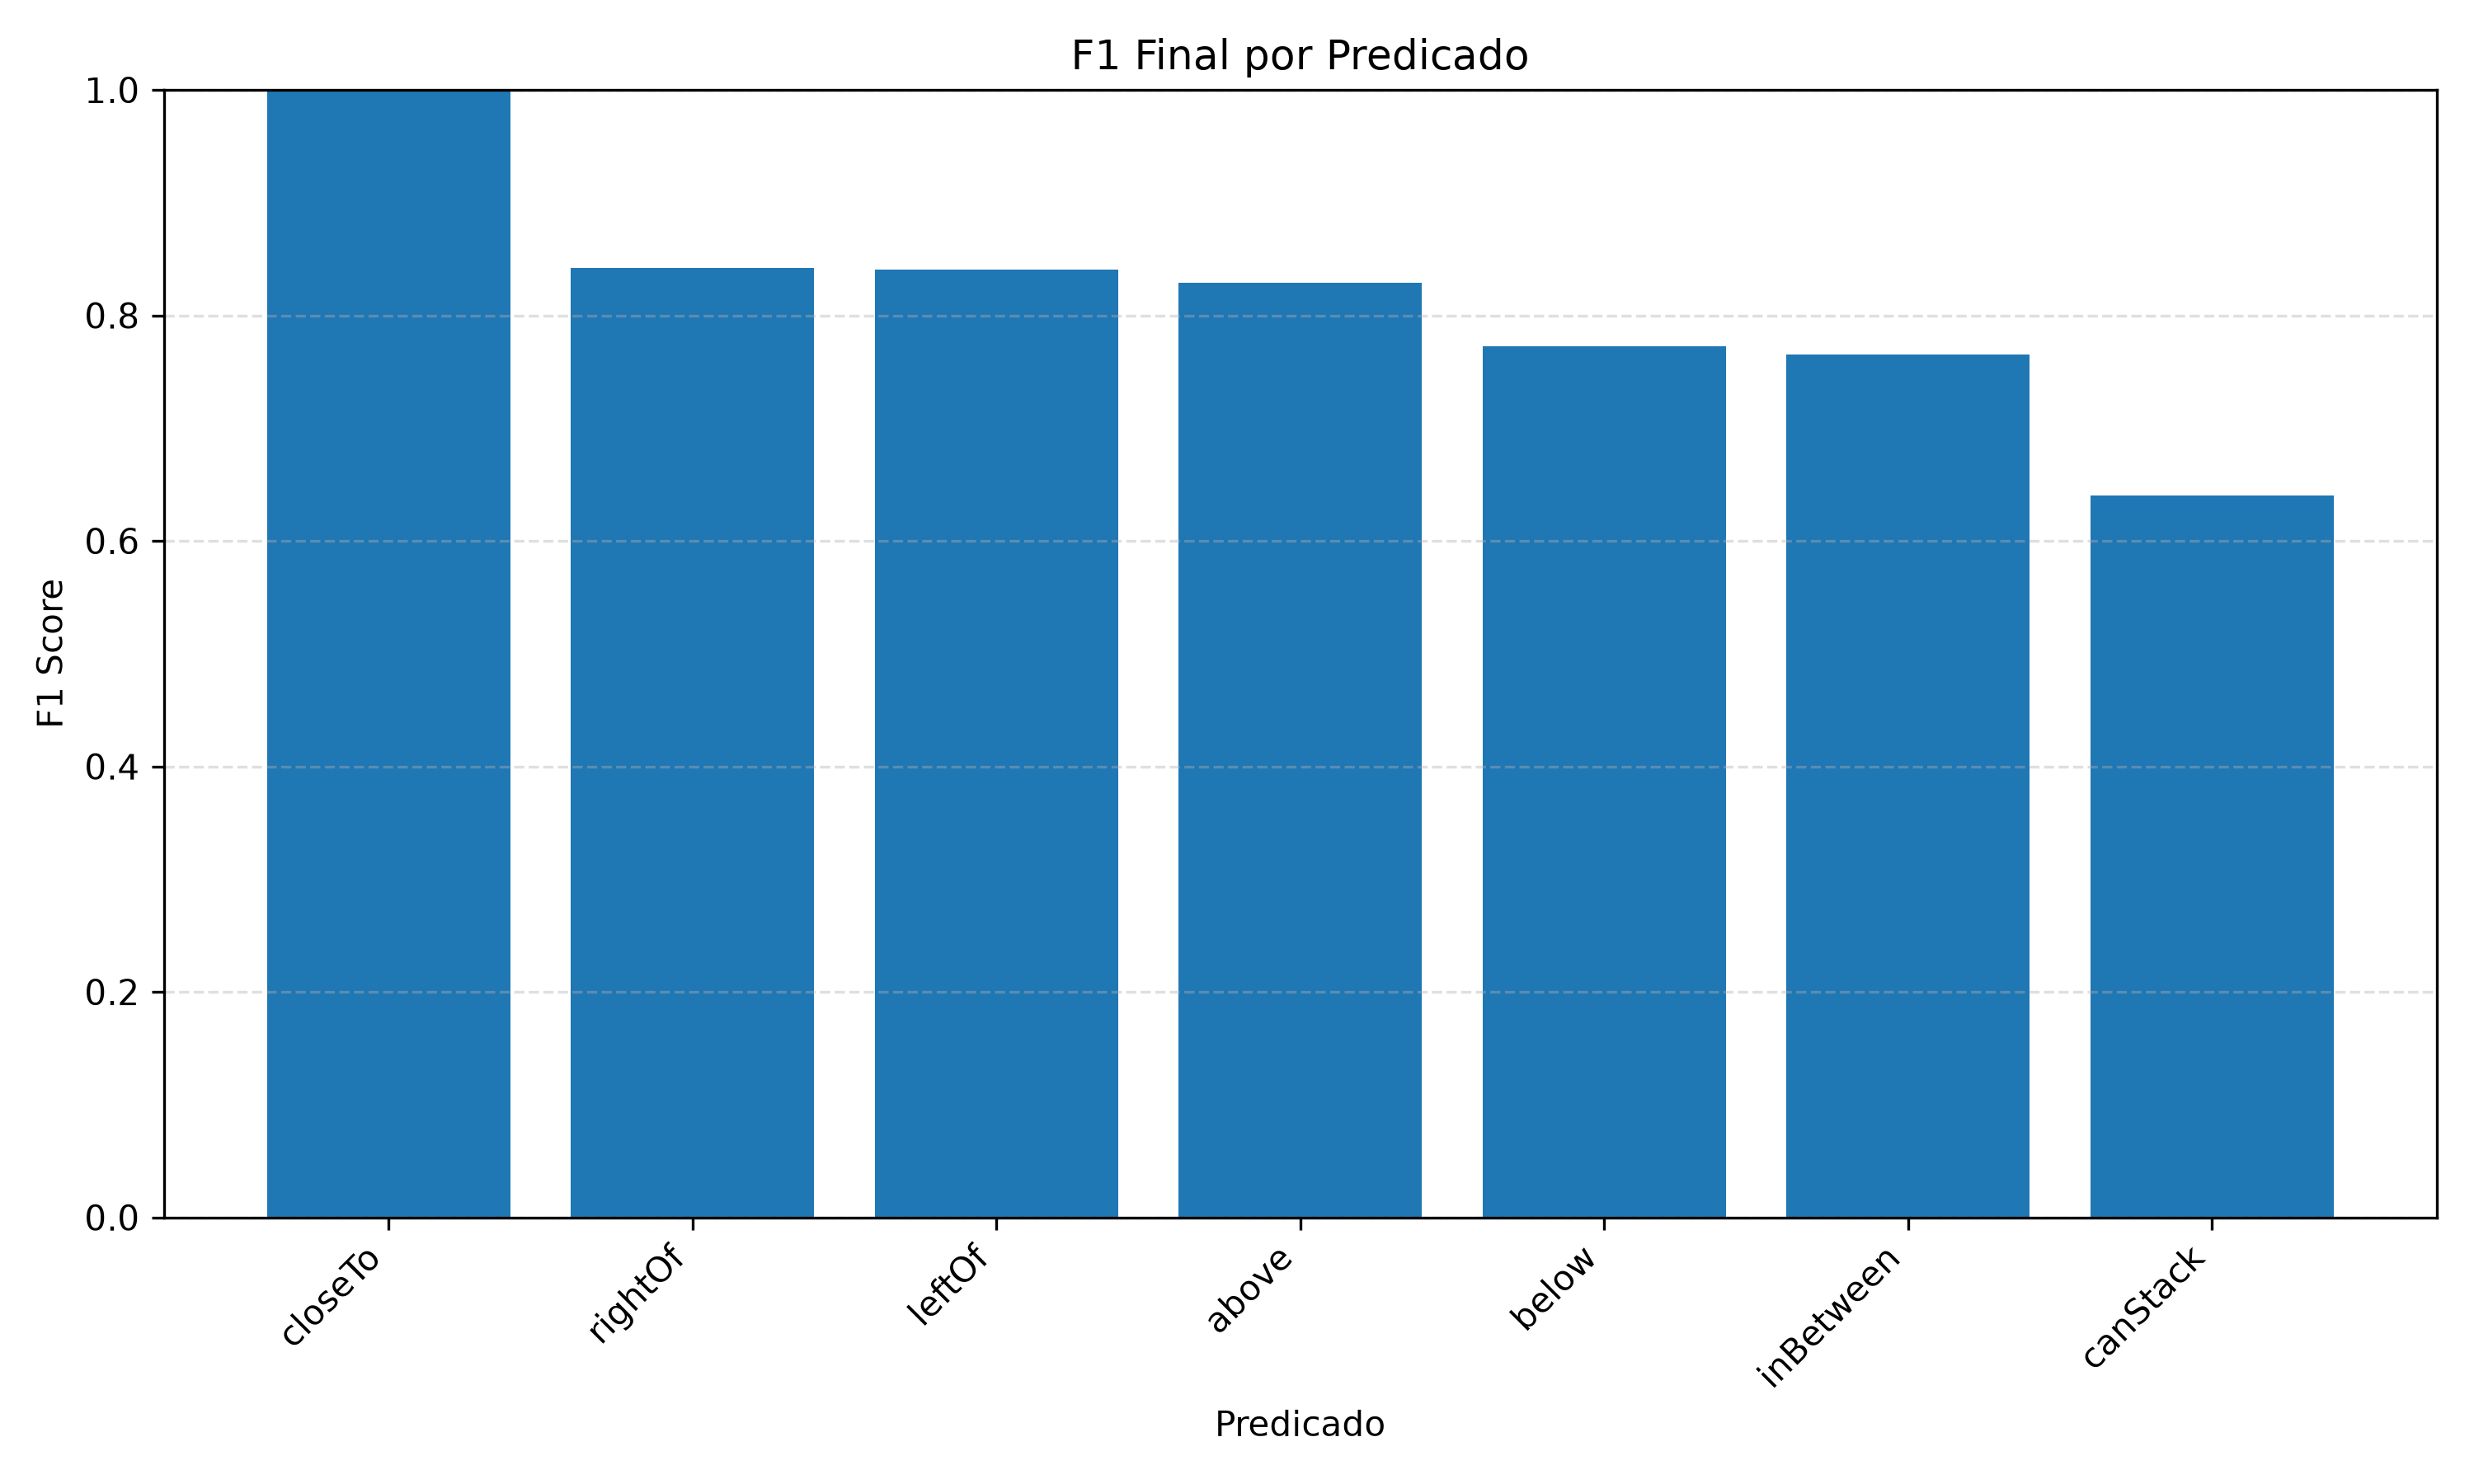

In [5]:
display(Image(filename=str(METRICS_DIR / "plots" / "f1_final_por_predicado.png")))